In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from lime import lime_image
from skimage.segmentation import mark_boundaries

C:\Users\arthur fernandes\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
modelo = load_model("../models/brain_tumor_cnn_v2.keras")

In [ ]:
imagem_path = "../datasets/yes/Tr-gl_18.jpg" # caminho da imagem que deseja analisar

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

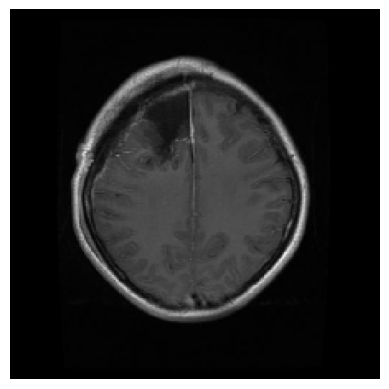

In [7]:
img = image.load_img(
    imagem_path, #mostra a imagem
    target_size=(224,224)
)

plt.imshow(img)

plt.axis("off")

In [ ]:
img_array = image.img_to_array(img) # converte a imagem em um array numpy

img_array = img_array / 255.0 # normaliza a imagem para valores entre 0 e 1

img_array = np.expand_dims(img_array, axis=0) # adiciona uma dimensão extra para representar o batch size
print(img_array.shape)

(1, 224, 224, 3)


In [ ]:
pred = modelo.predict(img_array) # faz a previsão da classe da imagem usando o modelo carregado
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
[[0.99999106]]


In [12]:
prob = float(pred[0][0])

if prob >= 0.5:
    classe = "Tumor"
else:
    classe = "Sem Tumor"

print(classe)
print(prob)

Tumor
0.9999910593032837


In [ ]:
explainer = lime_image.LimeImageExplainer() # cria um objeto LimeImageExplainer para gerar explicações para imagens

In [ ]:
def predict(images): # função de previsão que será usada pelo LIME para gerar explicações

    imagens = np.array(images)

    imagens = imagens.astype("float32") / 255.0

    return modelo.predict(imagens)

In [22]:
explanation = explainer.explain_instance(  # gera a explicação para a imagem usando o LIME 
    image.img_to_array(img).astype("double"), # converte a imagem em um array numpy e a transforma em double
    predict, # função de previsão que será usada pelo LIME para gerar explicações
    top_labels=1,
    hide_color=0,
    num_samples=2000
)

  0%|          | 0/2000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


  0%|          | 10/2000 [00:00<00:22, 86.54it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


  1%|          | 22/2000 [00:00<00:18, 104.42it/s]

...

 99%|█████████▉| 1982/2000 [00:19<00:00, 100.82it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


100%|█████████▉| 1993/2000 [00:19<00:00, 103.15it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


100%|██████████| 2000/2000 [00:19<00:00, 100.78it/s]


In [23]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=True
)

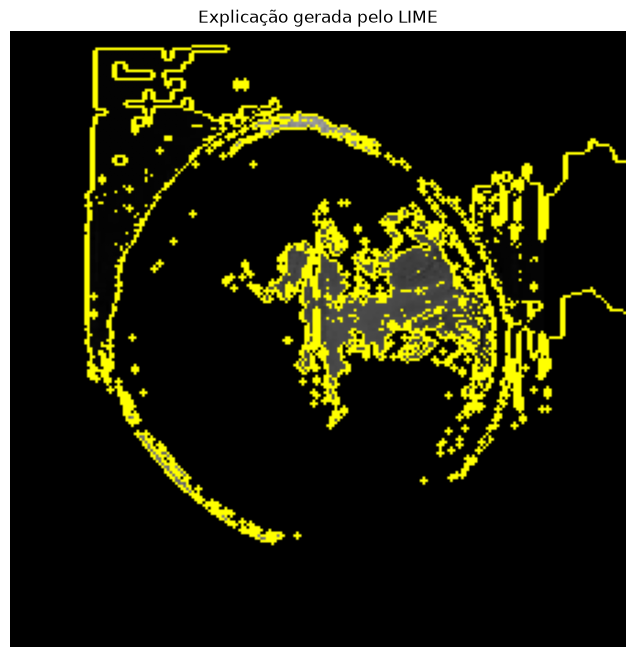

In [24]:
plt.figure(figsize=(8,8))

plt.imshow(mark_boundaries(temp / 255.0, mask))

plt.axis("off")

plt.title("Explicação gerada pelo LIME")

plt.show()

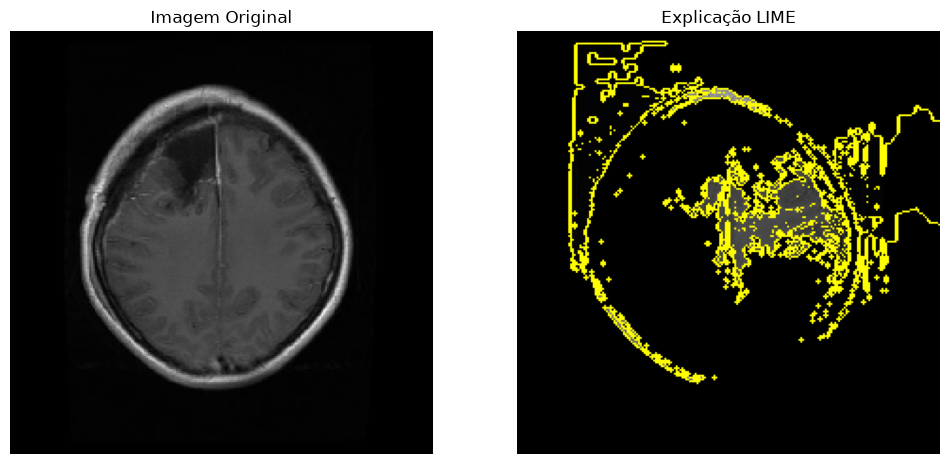

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].imshow(img)
ax[0].set_title("Imagem Original")
ax[0].axis("off")

ax[1].imshow(mark_boundaries(temp / 255.0, mask))
ax[1].set_title("Explicação LIME")
ax[1].axis("off")

plt.show()